<a href="https://colab.research.google.com/github/Patcaraporn-N/Ai-2-2568/blob/main/House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# กำหนดข้อมูลเป็น Dictionary โดยมี 'size' เป็นขนาดบ้านและ 'price' เป็นราคาบ้าน
data = {"size": [50, 75, 105, 130, 145, 170, 200],
        "price": [500_000, 1_000_000, 650_000, 1_200_000, 1_300_000, 1_850_000, 2_000_000] }

In [18]:
# แสดงผลข้อมูลที่กำหนดไว้
data

{'size': [50, 75, 105, 130, 145, 170, 200],
 'price': [500000, 1000000, 650000, 1200000, 1300000, 1850000, 2000000]}

### 1. การนำเข้าไลบรารีที่จำเป็น

In [19]:
# นำเข้าไลบรารีที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและสร้างแบบจำลอง
import pandas as pd # สำหรับการจัดการข้อมูลในรูปแบบ DataFrame
from sklearn.model_selection import train_test_split # สำหรับแบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ
from sklearn.linear_model import LinearRegression # สำหรับสร้างแบบจำลองการถดถอยเชิงเส้น
from sklearn.metrics import mean_squared_error, r2_score # สำหรับประเมินประสิทธิภาพของแบบจำลอง
import matplotlib.pyplot as plt # สำหรับการสร้างกราฟเพื่อแสดงผลข้อมูล
import numpy as np # สำหรับการคำนวณทางคณิตศาสตร์

### 2. เตรียมข้อมูล
แปลงข้อมูลพจนานุกรมที่มีอยู่ให้เป็น DataFrame และกำหนดคุณสมบัติ (X) และเป้าหมาย (y)

In [20]:
# แปลงข้อมูล Dictionary ให้เป็น Pandas DataFrame
df = pd.DataFrame(data)

# กำหนด 'size' เป็นตัวแปรอิสระ (X - features) และ 'price' เป็นตัวแปรตาม (y - target)
X = df[['size']]
y = df['price']

print("Features (X):")
print(X)
print("\nTarget (y):")
print(y)

Features (X):
   size
0    50
1    75
2   105
3   130
4   145
5   170
6   200

Target (y):
0     500000
1    1000000
2     650000
3    1200000
4    1300000
5    1850000
6    2000000
Name: price, dtype: int64


### 3. แยกข้อมูลออกเป็นชุดฝึกและชุดทดสอบ
เราจะใช้ 80% ของข้อมูลในการฝึกโมเดล และ 20% ที่เหลือสำหรับการทดสอบ

In [21]:
# แบ่งข้อมูลออกเป็นชุดฝึก (training set) และชุดทดสอบ (testing set)
# test_size=0.2 หมายถึง 20% ของข้อมูลจะถูกใช้เป็นชุดทดสอบ
# random_state=42 เพื่อให้ผลลัพธ์ของการแบ่งข้อมูลสามารถทำซ้ำได้ (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"ขนาดชุดฝึก: {len(X_train)}")
print(f"ขนาดชุดทดสอบ: {len(X_test)}")

ขนาดชุดฝึก: 5
ขนาดชุดทดสอบ: 2


### 4. สร้างและฝึกแบบจำลองการถดถอยเชิงเส้น

In [22]:
# สร้างอ็อบเจกต์ LinearRegression และทำการฝึกแบบจำลองด้วยชุดข้อมูลฝึก
model = LinearRegression()
model.fit(X_train, y_train)

# แสดงค่าสัมประสิทธิ์ (Coefficient) และค่าตัดแกน (Intercept) ของแบบจำลอง
print(f"ค่าสัมประสิทธิ์ (Coefficient): {model.coef_[0]:.2f}")
print(f"ค่าตัดแกน (Intercept): {model.intercept_:.2f}")

ค่าสัมประสิทธิ์ (Coefficient): 14439.25
ค่าตัดแกน (Intercept): -765887.85


### 5. ประเมินแบบจำลอง
เราจะใช้ Mean Squared Error (MSE) และ R-squared เพื่อประเมินประสิทธิภาพของแบบจำลอง

In [23]:
# ใช้แบบจำลองที่ฝึกแล้วทำนายราคาจากชุดข้อมูลทดสอบ
y_pred = model.predict(X_test)

# คำนวณ Mean Squared Error (MSE) เพื่อวัดความแตกต่างระหว่างค่าจริงและค่าที่ทำนาย
mse = mean_squared_error(y_test, y_pred)
# คำนวณ R-squared (R2) เพื่อวัดความสามารถในการอธิบายความแปรปรวนของแบบจำลอง
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 381133532404.58
R-squared (R2): -5.10


### 6. การทำนายราคาบ้านใหม่
ลองทำนายราคาสำหรับขนาดบ้านใหม่

In [24]:
# สร้าง DataFrame สำหรับขนาดบ้านใหม่ที่ต้องการทำนายราคา
new_house_sizes = pd.DataFrame({'size': [110, 160, 220]})
# ใช้แบบจำลองทำนายราคาสำหรับขนาดบ้านใหม่เหล่านี้
predicted_prices = model.predict(new_house_sizes)

# แสดงผลการทำนายราคาสำหรับแต่ละขนาดบ้านใหม่
for size, price in zip(new_house_sizes['size'], predicted_prices):
    print(f"สำหรับบ้านขนาด {size} ตร.ม. ราคาที่พยากรณ์คือ {price:,.2f} บาท")

สำหรับบ้านขนาด 110 ตร.ม. ราคาที่พยากรณ์คือ 822,429.91 บาท
สำหรับบ้านขนาด 160 ตร.ม. ราคาที่พยากรณ์คือ 1,544,392.52 บาท
สำหรับบ้านขนาด 220 ตร.ม. ราคาที่พยากรณ์คือ 2,410,747.66 บาท


### 7. แสดงผลลัพธ์
แสดงข้อมูลต้นฉบับ, จุดข้อมูลทดสอบ และเส้นถดถอยที่พยากรณ์ไว้

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

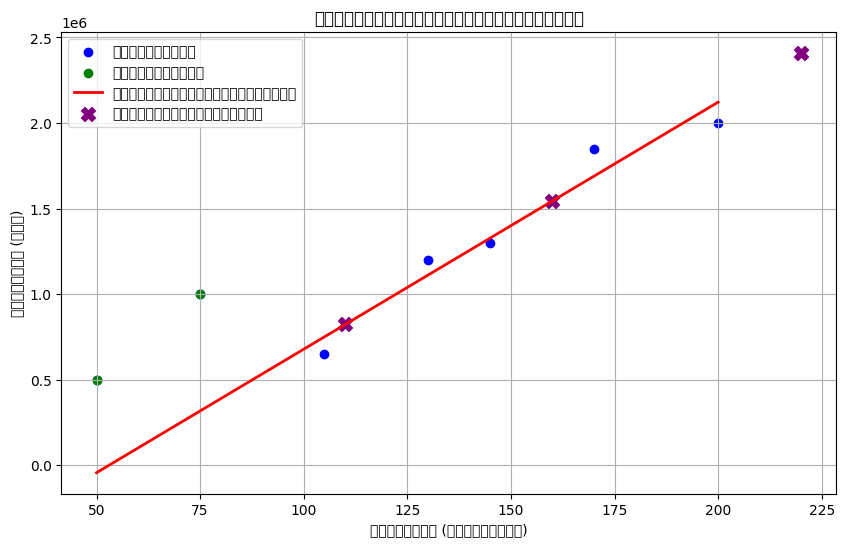

In [25]:
# กำหนดขนาดของกราฟ
plt.figure(figsize=(10, 6))
# พล็อตข้อมูลจริงด้วยจุดสีน้ำเงิน
plt.scatter(X, y, color='blue', label='ข้อมูลจริง')
# พล็อตข้อมูลชุดทดสอบด้วยจุดสีเขียว
plt.scatter(X_test, y_test, color='green', label='ข้อมูลทดสอบ')
# พล็อตเส้นถดถอยที่ได้จากแบบจำลองด้วยเส้นสีแดง
plt.plot(X, model.predict(X), color='red', linewidth=2, label='เส้นถดถอยที่พยากรณ์ไว้')
# พล็อตจุดราคาที่พยากรณ์ใหม่ด้วยเครื่องหมาย 'X' สีม่วง
plt.scatter(new_house_sizes, predicted_prices, color='purple', marker='X', s=100, label='ราคาที่พยากรณ์ใหม่')

# กำหนดชื่อเรื่องและป้ายกำกับแกนของกราฟ
plt.title('การทำนายราคาบ้านจากขนาดบ้าน')
plt.xlabel('ขนาดบ้าน (ตารางเมตร)')
plt.ylabel('ราคาบ้าน (บาท)')
# แสดงคำอธิบาย (legend) ของกราฟ
plt.legend()
# แสดงเส้นตารางในกราฟ
plt.grid(True)
# แสดงกราฟ
plt.show()